# Joint distributions

*Prerequisite: [Records and the Record family](02_records.ipynb). Joint
distributions produce `Record` samples, accept `Record` / dict input to
`log_prob`, and return `Record` moments — the Record notebook covers all
three.*

ProbPipe has four joint-distribution classes, each optimised for a
different situation:

| Class | When to reach for it | Key feature |
|---|---|---|
| `ProductDistribution` | Independent named components | `log_prob` = sum of marginals; nested dicts allowed |
| `SequentialJointDistribution` | Autoregressive dependence | Callables receive earlier draws |
| `JointGaussian` | Analytical Gaussian model | Exact closed-form `condition_on` |
| `JointEmpirical` / `NumericJointEmpirical` | MCMC / importance samples | Joint row resampling preserves correlation |

Every class returns its samples as a `Record` keyed by component name and
accepts the same structure when you ask for `log_prob`, `mean`, or
`variance`. Accessing a single component with bracket syntax (`joint["x"]`)
returns a *view* — a lightweight distribution that draws from the joint
under the hood and extracts the requested component, so marginal
operations interoperate correctly with correlated broadcasting.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal,
    Gamma,
    MultivariateNormal,
    ProductDistribution,
    SequentialJointDistribution,
    JointGaussian,
    JointEmpirical,
    NumericJointEmpirical,
    FlattenedView,
    sample,
    log_prob,
    mean,
    variance,
    condition_on,
)

key = jax.random.PRNGKey(0)

## 1. `ProductDistribution` — independent named components

The simplest joint. Components are listed as keyword arguments; each
keyword becomes the component name. Sampling draws every component
independently, log-prob is the sum of the marginals, conditioning drops
the conditioned components entirely.

In [2]:
joint = ProductDistribution(
    theta=Normal(loc=0.0, scale=1.0, name="theta"),
    sigma=Gamma(concentration=2.0, rate=1.0, name="sigma"),
)
print(joint)
print("fields:", joint.fields)
print("event_shapes:", joint.event_shapes)

ProductDistribution(theta=Normal, sigma=Gamma, name='product(sigma,theta)')
fields: ('sigma', 'theta')
event_shapes: {'sigma': (), 'theta': ()}


Sampling returns a `Record` keyed by component name. Every moment op
returns the same structure:

In [3]:
draw = sample(joint, key=jax.random.PRNGKey(10))
print("sample:", draw)
print("mean:", mean(joint))
print("variance:", variance(joint))

sample: Record(sigma=Array(1.4452835, dtype=float32), theta=Array(-1.8079674, dtype=float32))
mean: Record(sigma=Array(2., dtype=float32), theta=Array(0., dtype=float32))
variance: Record(sigma=Array(2., dtype=float32), theta=Array(1., dtype=float32))


`log_prob` accepts a `Record` or a dict with the same keys:

In [4]:
x = {"theta": jnp.array(0.5), "sigma": jnp.array(1.5)}
lp = log_prob(joint, x)
# Sum of marginals
lp_theta = log_prob(joint["theta"], x["theta"])
lp_sigma = log_prob(joint["sigma"], x["sigma"])
lp_f = float(lp)
lp_sum = float(lp_theta) + float(lp_sigma)
print(f"joint log_prob:    {lp_f:.4f}")
print(f"sum of marginals:  {lp_sum:.4f}  (match: {bool(jnp.isclose(lp_f, lp_sum))})")

joint log_prob:    -2.1385
sum of marginals:  -2.1385  (match: True)


### Accessing a component returns a view

`joint["theta"]` doesn't return the underlying `Normal` — it returns a
lightweight view that knows its parent joint. When sampled standalone, it
draws from the joint and extracts the component; when asked for moments,
it delegates to the parent. The extra indirection is what lets views
from the *same* parent interact correctly inside `@workflow_function`
broadcasting (covered in the [Broadcasting](03_broadcasting.ipynb)
notebook — two views from the same parent draw from a single shared
sample, preserving correlation).

In [5]:
theta_view = joint["theta"]
print("view:", theta_view)
print("  event_shape:", theta_view.event_shape)
print("  mean:", float(mean(theta_view)))
print("  sample (drawn via parent):",
      sample(theta_view, key=jax.random.PRNGKey(11), sample_shape=(3,)))

view: _RecordDistributionView(parent=ProductDistribution, field='theta')
  event_shape: ()
  mean: 0.0


  sample (drawn via parent): NumericRecord(sample=array(shape=(3,)))


### Conditioning drops components

`condition_on(joint, name=value)` returns a new joint over the
*unconditioned* components. For an independent `ProductDistribution`
this is straightforward — the remaining marginals are unchanged.

In [6]:
conditioned = condition_on(joint, theta=jnp.array(2.0))
print("after condition_on(theta=2.0):", conditioned)
print("remaining:", conditioned.fields)
print("sample:", sample(conditioned, key=jax.random.PRNGKey(12)))

after condition_on(theta=2.0): ProductDistribution(sigma=Gamma, name='product(sigma,theta)')
remaining: ('sigma',)
sample: Record(sigma=Array(1.9891622, dtype=float32))


### Multivariate components

Each component can be multivariate (`event_shape` nonempty). The
component names are unaffected.

ProductDistribution(pos=MultivariateNormal, vel=MultivariateNormal, name='product(pos,vel)')
event_shapes: {'pos': (2,), 'vel': (2,)}


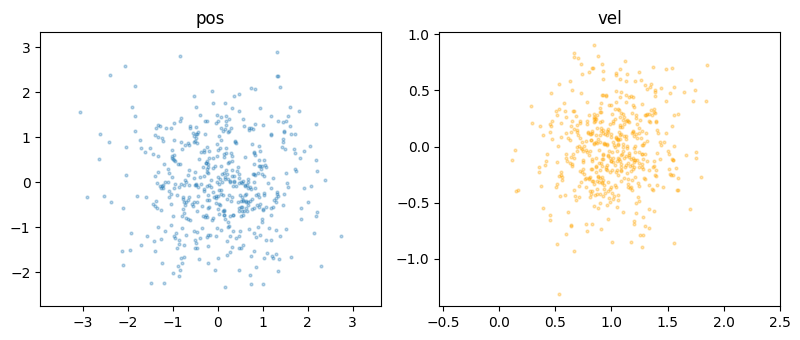

In [7]:
joint_mv = ProductDistribution(
    pos=MultivariateNormal(loc=jnp.zeros(2), cov=jnp.eye(2), name="pos"),
    vel=MultivariateNormal(loc=jnp.array([1.0, 0.0]), cov=0.1 * jnp.eye(2), name="vel"),
)
print(joint_mv)
print("event_shapes:", joint_mv.event_shapes)
draws = sample(joint_mv, key=jax.random.PRNGKey(13), sample_shape=(500,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.scatter(draws["pos"][:, 0], draws["pos"][:, 1], alpha=0.3, s=4)
ax1.set_title("pos"); ax1.axis("equal")
ax2.scatter(draws["vel"][:, 0], draws["vel"][:, 1], alpha=0.3, s=4, color="orange")
ax2.set_title("vel"); ax2.axis("equal")
plt.tight_layout(); plt.show()

### Nested components

Components can be organised as nested dicts for grouping — the nesting is
purely organisational (all the component distributions are still
independent) but carries through into samples and `log_prob` as nested
Records.

In [8]:
nested = ProductDistribution(
    physics={
        "force": Normal(loc=0.0, scale=1.0, name="force"),
        "mass": Gamma(concentration=2.0, rate=1.0, name="mass"),
    },
    noise=Normal(loc=0.0, scale=0.1, name="noise"),
)
print(nested)
draw = sample(nested, key=jax.random.PRNGKey(14))
print("sample:", draw)
print("  draw['physics']['force'] =", float(draw["physics"]["force"]))
print("  draw['physics', 'force'] =", float(draw["physics", "force"]))

ProductDistribution(physics={...}, noise=Normal, name='product(noise,physics)')
sample: Record(noise=Array(-0.06540143, dtype=float32), physics=Record(force=Array(-0.6304773, dtype=float32), mass=Array(1.0037069, dtype=float32)))
  draw['physics']['force'] = -0.6304773092269897
  draw['physics', 'force'] = -0.6304773092269897


## 2. `SequentialJointDistribution` — autoregressive dependence

When a component's distribution depends on *earlier* components, pass a
callable whose arguments name the earlier components. Sampling evaluates
the callable on the already-drawn values.

SequentialJointDistribution(theta=Normal, y=<callable>, name='sequential(theta,y)')


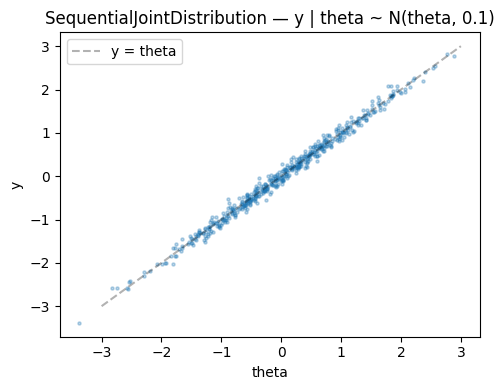

In [9]:
# Latent mean, then observation given the mean.
sjd = SequentialJointDistribution(
    theta=Normal(loc=0.0, scale=1.0, name="theta"),
    y=lambda theta: Normal(loc=theta, scale=0.1, name="y"),
)
print(sjd)
draws = sample(sjd, key=jax.random.PRNGKey(20), sample_shape=(500,))
plt.figure(figsize=(5, 4))
plt.scatter(draws["theta"], draws["y"], alpha=0.3, s=5)
plt.plot([-3, 3], [-3, 3], "k--", alpha=0.3, label="y = theta")
plt.xlabel("theta"); plt.ylabel("y"); plt.legend()
plt.title("SequentialJointDistribution — y | theta ~ N(theta, 0.1)")
plt.tight_layout(); plt.show()

Conditioning on an earlier component still works: the callable is bound
to the observed value, and the result is a (smaller) joint:

In [10]:
posterior_like = condition_on(sjd, theta=jnp.array(1.5))
print("after condition_on(theta=1.5):", posterior_like)
print("remaining:", posterior_like.fields)
draws = sample(posterior_like, key=jax.random.PRNGKey(21), sample_shape=(5,))
print("y draws (all centred near theta=1.5):", draws)

after condition_on(theta=1.5): SequentialJointDistribution(theta=Normal, y=<callable>, name='sequential(theta,y)')
remaining: ('y',)


y draws (all centred near theta=1.5): NumericRecordArray(batch_shape=(5,), y=array(shape=(5,)))


## 3. `JointGaussian` — exact joint with closed-form conditioning

`JointGaussian` holds a single multivariate Gaussian over the
concatenation of its components. `component_shapes` tells it how many
scalars belong to each named component. Samples come back as a `Record`
keyed by component name; `condition_on` performs the analytical Gaussian
conditioning update.

In [11]:
# Three components with sizes 1, 2, 1.  Correlations via off-diagonal cov.
jg = JointGaussian(
    mean=jnp.array([0.0, 1.0, -1.0, 2.0]),
    cov=jnp.array([
        [1.0, 0.5, 0.0, 0.2],
        [0.5, 1.0, 0.3, 0.0],
        [0.0, 0.3, 1.0, 0.0],
        [0.2, 0.0, 0.0, 0.5],
    ]),
    a=1, b=2, c=1,
)
print(jg)
print("fields:", jg.fields)
print("mean:", mean(jg))

JointGaussian(a=1, b=2, c=1, name='joint_gaussian(a,b,c)')
fields: ('a', 'b', 'c')
mean: Record(a=array(shape=(1,)), b=array(shape=(2,)), c=array(shape=(1,)))


In [12]:
# condition_on performs exact Gaussian conditioning — the resulting joint
# has an updated (smaller) mean vector and covariance.
cond = condition_on(jg, a=jnp.array([0.5]))
print("after condition_on(a=[0.5]):", cond)
print("  fields:", cond.fields)
print("  mean (posterior):", mean(cond))

after condition_on(a=[0.5]): JointGaussian(b=2, c=1, name='joint_gaussian(a,b,c)')
  fields: ('b', 'c')
  mean (posterior): Record(b=array(shape=(2,)), c=array(shape=(1,)))


## 4. `JointEmpirical` — MCMC samples with correlation-preserving resampling

`JointEmpirical` wraps a batch of pre-drawn samples, one per component.
Re-sampling draws joint rows (not per-component marginals), so
correlations between components are preserved. Conditioning uses nearest-
neighbour resampling: pick the rows whose conditioned fields are closest
to the observed value and draw from those.

A construction detail: when every component is numeric, `JointEmpirical`
dispatches to `NumericJointEmpirical`, which adds `SupportsLogProb` (via a
Gaussian approximation) plus `SupportsMean` / `SupportsVariance`.
Non-numeric components stay on the generic `JointEmpirical` and expose
only sampling + conditioning.

In [13]:
# Correlated samples from a latent AR(1): x_t = 0.6*x_{t-1} + eps
rng = np.random.default_rng(0)
n = 1000
x = np.zeros(n)
for t in range(1, n):
    x[t] = 0.6 * x[t - 1] + rng.normal() * 0.5
y = 0.5 * x + rng.normal(size=n) * 0.2
je = NumericJointEmpirical(x=jnp.asarray(x), y=jnp.asarray(y))
print(je)
print("fields:", je.fields)
print("mean:", mean(je))
print("variance:", variance(je))

NumericJointEmpirical(name='joint_empirical(x,y)')
fields: ('x', 'y')
mean: Record(x=Array(-0.05983598, dtype=float32), y=Array(-0.03164241, dtype=float32))
variance: Record(x=Array(0.3741798, dtype=float32), y=Array(0.1427942, dtype=float32))


Row resampling preserves the x–y correlation: resampled pairs should
still lie along the line y ≈ 0.5 x, not scattered independently.

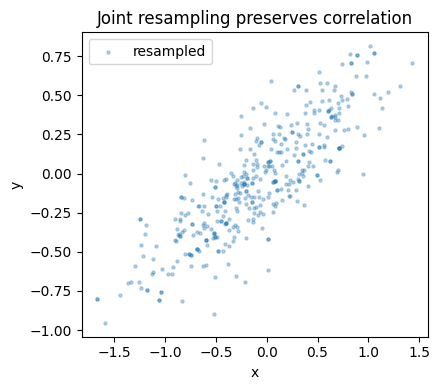

In [14]:
resampled = sample(je, key=jax.random.PRNGKey(30), sample_shape=(400,))
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(np.asarray(resampled["x"]), np.asarray(resampled["y"]),
           alpha=0.3, s=5, label="resampled")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Joint resampling preserves correlation")
ax.legend()
plt.tight_layout(); plt.show()

Conditioning on a value picks rows whose `x` is close to the target:

In [15]:
cond = condition_on(je, x=jnp.array(1.0))
print("after condition_on(x=1.0):", cond)
# Sample many y values from the conditional and check their mean is ≈0.5
y_cond = sample(cond, key=jax.random.PRNGKey(31), sample_shape=(200,))
print("E[y | x=1.0] ≈", float(jnp.mean(y_cond["y"])), "(expect ≈ 0.5)")

after condition_on(x=1.0): NumericJointEmpirical(name='joint_empirical(x,y)')


E[y | x=1.0] ≈ -0.02428206242620945 (expect ≈ 0.5)


## 5. Flat-vector view for flat algorithms

Many downstream tools (optimisers, MCMC samplers, simple neural nets)
only understand a flat vector. `FlattenedView(joint)` wraps any joint
as a single-array distribution with `event_shape=(flat_size,)` —
internally it flattens the component Record on the way out and
unflattens the vector on the way in to `log_prob`.

In [16]:
flat = FlattenedView(joint)  # joint from section 1
print(flat)
print("event_shape:", flat.event_shape, "(sigma scalar + theta scalar = 2)")
print("fields (alphabetical flattening order):", joint.fields)

# Sampling + unflatten round-trips through the joint's own Record schema
flat_draw = sample(flat, key=jax.random.PRNGKey(40))
print("\nflat sample:     ", flat_draw)
print("unflatten_value: ", joint.unflatten_value(flat_draw))

# log_prob agrees as long as you use the flat ordering (alphabetical):
x_record = {"sigma": 1.5, "theta": 0.5}
x_flat = jnp.array([1.5, 0.5])  # [sigma, theta]
print("\nlog_prob(joint, record):", float(log_prob(joint, x_record)))
print("log_prob(flat,  vector):", float(log_prob(flat, x_flat)))

FlattenedView(base=ProductDistribution, event_shape=(2,))
event_shape: (2,) (sigma scalar + theta scalar = 2)
fields (alphabetical flattening order): ('sigma', 'theta')



flat sample:      NumericRecord(sample=array(shape=(2,)))
unflatten_value:  NumericRecord(sigma=Array(1.1581354, dtype=float32), theta=Array(0.28211874, dtype=float32))

log_prob(joint, record): -2.1384735107421875
log_prob(flat,  vector): -2.1384735107421875


## 6. Choosing between the four

- Need independent components? Use `ProductDistribution`. It's the
  lowest-overhead option and its nested-dict form handles arbitrary
  organisational hierarchies.
- Need conditional dependence between components? `SequentialJointDistribution`.
  Bind each downstream component with a callable of the earlier ones.
- Gaussian joint where you want *exact* `condition_on`?
  `JointGaussian` gives you closed-form conditioning in one matrix
  solve; don't reach for MCMC if the joint is already Gaussian.
- You already have posterior draws and want to treat them as a joint?
  `JointEmpirical` (or `NumericJointEmpirical` for fully numeric
  components). Row resampling preserves every pairwise correlation
  in your sample set.

All four share the same surface: `sample` / `log_prob` (when available) /
`mean` / `variance` / `condition_on` / `fields` / bracket access.
A downstream workflow treats them interchangeably as long as it only
uses the capabilities the particular joint supports.